# Notebook 6.3 — Final Clean Ablation Table (BDSE in-domain 80/20 + Cross-Dataset)
### DEEP-LEARNING BASED EMOTION RECOGNITION IN BANGLADESHI STREET DOGS

**Why this notebook:**
NB6.2 (calibration probe) demonstrated that ADaS produces real, statistically significant
effects when both variants are trained from scratch with the same seed and identical
data pipelines. NB6.1 had a bug (state leakage between trainer calls) that caused
bit-identical results.

NB6.2 evaluated BDSE on the **full training set** (for probability-level comparison),
which is fine for the calibration probe but not appropriate for a publication ablation
table — the BDSE in-domain number leaks training data into the test set.

**What this notebook does:**
Re-runs all 4 ablation variants — `full`, `no_dad`, `no_adas`, `no_anchor` —
with the **publication-grade NB6 protocol**:
- BDSE 80/20 stratified split (per seed)
- 5 seeds: [13, 42, 101, 257, 999]
- Train each variant on 80% of BDSE; evaluate on 20% held-out (in-domain)
- Train each variant on 100% of BDSE; evaluate on Shanbalico / Devzohaib / DEBIw (cross-dataset)
- Same evaluation protocol as NB6 — produces directly-comparable numbers

**The trainer is the same as NB6.2 (the corrected one) with explicit `use_adas`,
`use_anchor_init`, `use_anchor_loss`, `use_div_loss` flags — no state leakage possible.**

**Outputs:**
- `cross_dataset_ablation_results_FINAL.csv` — per-(variant, target, seed) raw results
- `cross_dataset_ablation_summary_FINAL.csv` — mean ± 95% CI per cell
- `ablation_wilcoxon_FINAL.csv` — paired Wilcoxon: full vs each variant
- `figure_ablation_FINAL.pdf` — publication ablation figure

**Compute:** ~50 min on Kaggle T4 (4 variants × 5 seeds × 2 trainings = 40 trainings)


In [1]:
%%capture
!pip install transformers accelerate scikit-learn scipy matplotlib seaborn pillow requests -q


In [2]:
import os, sys, json, time, warnings, gc
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, t as student_t
from sklearn.metrics import f1_score, balanced_accuracy_score, log_loss
from sklearn.model_selection import StratifiedShuffleSplit
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f} GB")


Device: cuda
GPU: Tesla T4  VRAM: 15.6 GB


In [3]:
CFG = dict(
    bdse_feat_dir       = '/kaggle/input/datasets/rohulaminlabid/phase1-nb2-inputs',
    manifests_dir       = '/kaggle/input/datasets/rohulaminlabid/benchmard-datasets',
    shanbalico_img_dir  = '/kaggle/input/datasets/danielshanbalico/dog-emotion/Dog Emotion',
    devzohaib_img_dir   = '/kaggle/input/datasets/devzohaib/dog-emotions-prediction/images',
    debiw_img_dir       = '/kaggle/input/datasets/rohulaminlabid/debiw-dataset',
    feat_cache_dir      = '/kaggle/working/feat_cache',
    output_dir          = '/kaggle/working/nb63_outputs',

    siglip_id           = 'google/siglip-base-patch16-224',
    feat_dim            = 768,
    extract_batch       = 64,

    n_proto_per_class   = 6,
    tau                 = 0.07,
    lambda_anchor       = 0.1,
    mu_div              = 0.05,
    lr                  = 1e-3,
    epochs              = 150,
    patience            = 20,
    batch_size          = 256,

    n_seeds             = 5,
    seeds               = [13, 42, 101, 257, 999],
    indomain_test_frac  = 0.20,

    classes3            = ['A', 'N', 'H'],
    classes2            = ['A', 'N'],
    debiw_workers       = 20,
    debiw_timeout       = 12,
    debiw_retries       = 2,
)

for d in [CFG['debiw_img_dir'], CFG['feat_cache_dir'], CFG['output_dir']]:
    os.makedirs(d, exist_ok=True)

CLASS3_TO_IDX = {c: i for i, c in enumerate(CFG['classes3'])}
CLASS2_TO_IDX = {c: i for i, c in enumerate(CFG['classes2'])}
print("Config loaded.")


Config loaded.


In [8]:
# Load SigLIP once; keep frozen on GPU for feature extraction
from transformers import AutoProcessor, AutoModel

print("Loading SigLIP-Base/16 …")
_siglip_processor = AutoProcessor.from_pretrained(CFG['siglip_id'])
_siglip_model     = AutoModel.from_pretrained(CFG['siglip_id']).to(DEVICE).eval()
for p in _siglip_model.parameters():
    p.requires_grad_(False)
print("SigLIP loaded.")

def siglip_image_features(image_paths, batch_size=None):
    """Return L2-normalised SigLIP image features (N, 768) for a list of paths.
    Invalid / missing images are replaced with zero vectors; returned valid_mask
    is a boolean array marking which rows are real."""
    bs = batch_size or CFG['extract_batch']
    all_feats, valid_mask = [], []
    for i in range(0, len(image_paths), bs):
        batch = image_paths[i:i+bs]
        imgs, ok = [], []
        for p in batch:
            try:
                imgs.append(Image.open(p).convert('RGB'))
                ok.append(True)
            except Exception:
                imgs.append(Image.new('RGB', (224, 224), 0))
                ok.append(False)
        inp = _siglip_processor(images=imgs, return_tensors='pt', padding=True)
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        with torch.no_grad():
            outputs = _siglip_model.get_image_features(**inp)
            feats = outputs.pooler_output  # This extracts the actual feature tensor
            feats = F.normalize(feats, dim=1)
        all_feats.append(feats.cpu().numpy())
        valid_mask.extend(ok)
        if (i // bs) % 20 == 0:
            print(f"  {i+len(batch)}/{len(image_paths)} images processed", end='\r')
    print()
    return np.concatenate(all_feats, axis=0), np.array(valid_mask, dtype=bool)

def siglip_text_features(texts):
    """Return L2-normalised SigLIP text features for a list of strings."""
    inp = _siglip_processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    inp = {k: v.to(DEVICE) for k, v in inp.items()}
    with torch.no_grad():
        outputs = _siglip_model.get_image_features(**inp)
        feats = outputs.pooler_output  # This extracts the actual tensor
        feats = F.normalize(feats, dim=1)
    return feats.cpu().numpy()

def cache_path(name):
    return os.path.join(CFG['feat_cache_dir'], f'{name}.npy')

def load_or_extract(name, image_paths, label_array):
    """Load cached features or extract and cache them."""
    fp = cache_path(name)
    fp_meta = fp.replace('.npy', '_meta.csv')
    if os.path.exists(fp) and os.path.exists(fp_meta):
        print(f"[cache hit] {name}")
        feats = np.load(fp)
        meta  = pd.read_csv(fp_meta)
        return feats, meta
    print(f"[extracting] {name} ({len(image_paths)} images) …")
    feats, valid = siglip_image_features(image_paths)
    meta = pd.DataFrame({'path': image_paths, 'label': label_array, 'valid': valid})
    np.save(fp, feats)
    meta.to_csv(fp_meta, index=False)
    print(f"  Saved to {fp}")
    return feats, meta


Loading SigLIP-Base/16 …


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP loaded.


In [9]:
print("Loading BDSE Phase 1 artifacts …")
bdse_feats_siglip = np.load(os.path.join(CFG['bdse_feat_dir'], 'features_siglip.npy'))
bdse_feat_index   = pd.read_csv(os.path.join(CFG['bdse_feat_dir'], 'feature_index.csv'))
text_anchors_np   = np.load(os.path.join(CFG['bdse_feat_dir'], 'text_anchors_siglip.npy'))

splits_path = os.path.join(CFG['bdse_feat_dir'], 'bdse_dogid_splits.csv')
if not os.path.exists(splits_path):
    splits_path = os.path.join(CFG['manifests_dir'], 'bdse_dogid_splits.csv')
bdse_splits = pd.read_csv(splits_path)
bdse_merged = bdse_feat_index.merge(bdse_splits[['image_id','dog_id','label','fold']],
                                     on='image_id', how='inner')
bdse_X = bdse_feats_siglip[bdse_merged.index.values]
bdse_y = bdse_merged['label_x'].map(CLASS3_TO_IDX).values

adas_cols = ['n_A', 'n_N', 'n_H']
if all(c in bdse_merged.columns for c in adas_cols):
    totals = bdse_merged[adas_cols].sum(axis=1).clip(lower=1)
    bdse_soft = (bdse_merged[adas_cols].values / totals.values[:,None]).astype(np.float32)
    bdse_wts  = (totals / totals.max()).values.astype(np.float32)
else:
    bdse_soft = np.eye(3)[bdse_y].astype(np.float32)
    bdse_wts  = np.ones(len(bdse_y), dtype=np.float32)

TEXT_ANCHORS = torch.tensor(text_anchors_np, dtype=torch.float32)
PROTO_CLASS_MAP3 = {0: list(range(0,6)), 1: list(range(6,12)), 2: list(range(12,18))}
PROTO_CLASS_MAP2 = {0: list(range(0,6)), 1: list(range(6,12))}
print(f"BDSE rows: {len(bdse_merged)}  Text anchors: {TEXT_ANCHORS.shape}")


Loading BDSE Phase 1 artifacts …
BDSE rows: 500  Text anchors: torch.Size([18, 768])


In [6]:


debiw_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'debiw_processed.csv'))



In [10]:
shan_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'shanbalico_processed.csv'))
shan_main = shan_manifest[shan_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def res_shan(fp):
    fn = os.path.basename(fp); cls = fp.split('/')[-2]
    return os.path.join(CFG['shanbalico_img_dir'], cls, fn)
shan_paths = [res_shan(p) for p in shan_main['filepath']]
shan_X_raw, shan_meta = load_or_extract('shanbalico_main', shan_paths, shan_main['bdse_label'].values)
shan_v = shan_meta['valid'].values.astype(bool)
shan_X = shan_X_raw[shan_v]; shan_y3 = shan_meta['label'][shan_v].map(CLASS3_TO_IDX).values

dev_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'devzohaib_processed.csv'))
dev_main = dev_manifest[dev_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def res_dev(fp):
    parts = fp.split('/'); return os.path.join(CFG['devzohaib_img_dir'], parts[-2], parts[-1])
dev_paths = [res_dev(p) for p in dev_main['filepath']]
dev_X_raw, dev_meta = load_or_extract('devzohaib_main', dev_paths, dev_main['bdse_label'].values)
dev_v = dev_meta['valid'].values.astype(bool)
dev_X = dev_X_raw[dev_v]; dev_y3 = dev_meta['label'][dev_v].map(CLASS3_TO_IDX).values

debiw_main = debiw_manifest[debiw_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
debiw_paths = [os.path.join(CFG['debiw_img_dir'], fn) for fn in debiw_main['image_filename']]
debiw_X_raw, debiw_meta = load_or_extract('debiw_main', debiw_paths, debiw_main['bdse_label'].values)
debiw_v = debiw_meta['valid'].values.astype(bool)
debiw_X = debiw_X_raw[debiw_v]; debiw_y2 = debiw_meta['label'][debiw_v].map(CLASS2_TO_IDX).values

print(f"Shan: {shan_X.shape}  Dev: {dev_X.shape}  DEBIw: {debiw_X.shape}")


[extracting] shanbalico_main (3000 images) …
  2624/3000 images processed
  Saved to /kaggle/working/feat_cache/shanbalico_main.npy
[extracting] devzohaib_main (8410 images) …
  7744/8410 images processed
  Saved to /kaggle/working/feat_cache/devzohaib_main.npy
[extracting] debiw_main (5335 images) …


The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


  5184/5335 images processed
  Saved to /kaggle/working/feat_cache/debiw_main.npy
Shan: (3000, 768)  Dev: (8410, 768)  DEBIw: (5335, 768)


In [11]:
class PEACEHead(nn.Module):
    def __init__(self, text_anchors, proto_class_map,
                 use_anchor_init=True, tau=0.07,
                 lambda_anchor=0.1, mu_div=0.05):
        super().__init__()
        ta_norm = F.normalize(text_anchors.float(), dim=1)
        self.register_buffer('text_anchors', ta_norm)
        if use_anchor_init:
            self.prototypes = nn.Parameter(ta_norm.clone())
        else:
            torch.manual_seed(0)
            init = torch.randn_like(ta_norm) * 0.1
            self.prototypes = nn.Parameter(F.normalize(init, dim=1))
        self.proto_class_map = proto_class_map
        self.n_classes = len(proto_class_map)
        self.tau = tau
        self.lambda_anchor = lambda_anchor
        self.mu_div = mu_div
    def forward(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in range(self.n_classes):
            out.append(torch.logsumexp(sims[:, self.proto_class_map[c]], dim=1, keepdim=True))
        return torch.cat(out, dim=1)
    def logits_2class(self, x):
        x_n = F.normalize(x, dim=1); p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        return torch.cat([torch.logsumexp(sims[:, self.proto_class_map.get(c, [c*6+j for j in range(6)])],
                                          dim=1, keepdim=True) for c in [0,1]], dim=1)
    def anchor_loss(self):
        return torch.mean((F.normalize(self.prototypes, dim=1) - self.text_anchors)**2)
    def diversity_loss(self):
        p_n = F.normalize(self.prototypes, dim=1); sim = p_n @ p_n.T
        n = p_n.size(0); mask = ~torch.eye(n, dtype=torch.bool, device=p_n.device)
        return sim[mask].mean()


In [12]:
def train_peace_variant(X_tr, y_tr, soft_labels, sample_weights,
                          variant, n_classes=3, seed=42, device=DEVICE):
    """
    variant ∈ {'full', 'no_dad', 'no_adas', 'no_anchor'}
      full      → use all components
      no_dad    → use ADaS + anchor init/loss; disable diversity loss
      no_adas   → use anchor init/loss + diversity loss; disable ADaS (one-hot, uniform weights)
      no_anchor → use ADaS + diversity loss; random init, no anchor loss
    """
    use_adas        = (variant != 'no_adas')
    use_anchor_init = (variant != 'no_anchor')
    use_anchor_loss = (variant != 'no_anchor')
    use_div         = (variant != 'no_dad')

    torch.manual_seed(seed); np.random.seed(seed)
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, vl_idx = next(sss.split(X_tr, y_tr))
    X_trn, X_vl = X_t[tr_idx], X_t[vl_idx]
    y_trn, y_vl = y_t[tr_idx], y_t[vl_idx]

    if use_adas:
        sl_trn = torch.tensor(soft_labels[tr_idx], dtype=torch.float32)
        wt_trn = torch.tensor(sample_weights[tr_idx], dtype=torch.float32)
    else:
        sl_trn = F.one_hot(y_trn, n_classes).float()
        wt_trn = torch.ones(len(y_trn))

    tr_dl = DataLoader(TensorDataset(X_trn, y_trn, sl_trn, wt_trn),
                       batch_size=CFG['batch_size'], shuffle=True)

    pcm = PROTO_CLASS_MAP3 if n_classes==3 else PROTO_CLASS_MAP2
    ta  = TEXT_ANCHORS if n_classes==3 else TEXT_ANCHORS[:12]
    model = PEACEHead(ta, pcm, use_anchor_init=use_anchor_init,
                       tau=CFG['tau'],
                       lambda_anchor=CFG['lambda_anchor'],
                       mu_div=CFG['mu_div']).to(device)

    opt = Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=CFG['epochs'])
    best_f1, best_state, no_imp = 0.0, None, 0

    for ep in range(CFG['epochs']):
        model.train()
        for xb, _, sl, wt in tr_dl:
            xb, sl, wt = xb.to(device), sl.to(device), wt.to(device)
            logits = model(xb)
            log_p  = F.log_softmax(logits, dim=1)
            ce     = -(sl * log_p).sum(dim=1)
            loss   = (wt * ce).mean()
            if use_anchor_loss:
                loss = loss + CFG['lambda_anchor'] * model.anchor_loss()
            if use_div:
                loss = loss + CFG['mu_div'] * model.diversity_loss()
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            vp = model(X_vl.to(device)).argmax(1).cpu().numpy()
        vf1 = f1_score(y_vl.numpy(), vp, average='macro', zero_division=0)
        if vf1 > best_f1:
            best_f1, best_state, no_imp = vf1, deepcopy(model.state_dict()), 0
        else:
            no_imp += 1
        if no_imp >= CFG['patience']: break

    model.load_state_dict(best_state); model.eval()
    return model


In [13]:
def _ece(probs, onehot, n_bins=15):
    conf = probs.max(1); acc = (probs.argmax(1) == onehot.argmax(1)).astype(float)
    bins = np.linspace(0, 1, n_bins+1); ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0: ece += m.sum() * abs(conf[m].mean() - acc[m].mean())
    return ece / len(conf)

def evaluate_peace(model, X_te, y_te, n_classes=3, two_class_mode=False, device=DEVICE):
    X_t = torch.tensor(X_te, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model.logits_2class(X_t) if two_class_mode else model(X_t)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(1); nc = probs.shape[1]; classes = list(range(nc))
    mf1 = f1_score(y_te, preds, average='macro', labels=classes, zero_division=0)
    bal = balanced_accuracy_score(y_te, preds)
    pcf1 = f1_score(y_te, preds, average=None, labels=classes, zero_division=0).tolist()
    ece = _ece(probs, np.eye(nc)[y_te])
    return dict(macro_f1=mf1, balanced_acc=bal, per_class_f1=pcf1, ece=ece, preds=preds, probs=probs)


In [14]:
print("=" * 65)
print("FINAL ABLATION — 4 variants × 5 seeds × {BDSE in-domain, Shan, Dev, DEBIw}")
print("=" * 65)

VARIANTS = ['full', 'no_dad', 'no_adas', 'no_anchor']
all_results = []

def record(variant, train_src, test_tgt, seed, n_classes, res, note=''):
    row = dict(variant=variant, train_src=train_src, test_tgt=test_tgt,
               seed=seed, n_classes=n_classes, note=note,
               macro_f1=round(res['macro_f1'],6),
               balanced_acc=round(res['balanced_acc'],6),
               ece=round(res['ece'],6))
    pcf1 = res.get('per_class_f1', [])
    for i, lab in enumerate((['A','N','H'] if n_classes==3 else ['A','N'])):
        row[f'f1_{lab}'] = round(pcf1[i],6) if i < len(pcf1) else None
    all_results.append(row)

for variant in VARIANTS:
    print(f"\n--- Variant: {variant} ---")
    for s_idx, seed in enumerate(CFG['seeds']):
        t0 = time.time()

        # ── In-domain BDSE: 80/20 stratified split (per seed) ──
        sss = StratifiedShuffleSplit(n_splits=1,
                                       test_size=CFG['indomain_test_frac'],
                                       random_state=seed)
        tr_idx, te_idx = next(sss.split(bdse_X, bdse_y))
        soft_tr = bdse_soft[tr_idx]; wts_tr = bdse_wts[tr_idx]
        m_id = train_peace_variant(bdse_X[tr_idx], bdse_y[tr_idx],
                                     soft_tr, wts_tr,
                                     variant=variant, n_classes=3, seed=seed)
        r = evaluate_peace(m_id, bdse_X[te_idx], bdse_y[te_idx], 3)
        record(variant, 'BDSE', 'BDSE', seed, 3, r, 'in-domain (80/20)')

        # ── Cross-dataset: train on FULL BDSE, evaluate on each external set ──
        m_full = train_peace_variant(bdse_X, bdse_y,
                                       bdse_soft, bdse_wts,
                                       variant=variant, n_classes=3, seed=seed)
        r = evaluate_peace(m_full, shan_X, shan_y3, 3)
        record(variant, 'BDSE', 'Shanbalico', seed, 3, r)

        r = evaluate_peace(m_full, dev_X, dev_y3, 3)
        record(variant, 'BDSE', 'Devzohaib', seed, 3, r)

        r = evaluate_peace(m_full, debiw_X, debiw_y2, 3, two_class_mode=True)
        r['macro_f1']     = f1_score(debiw_y2, r['preds'], average='macro', labels=[0,1], zero_division=0)
        r['per_class_f1'] = f1_score(debiw_y2, r['preds'], average=None, labels=[0,1], zero_division=0).tolist()
        record(variant, 'BDSE', 'DEBIw(A/N)', seed, 2, r, '2-class')

        in_dom = all_results[-4]['macro_f1']
        sh = all_results[-3]['macro_f1']
        dv = all_results[-2]['macro_f1']
        db = all_results[-1]['macro_f1']
        print(f"  seed={seed:4d}  in-dom={in_dom:.4f}  Shan={sh:.4f}  Dev={dv:.4f}  DEBIw={db:.4f}  ({time.time()-t0:.0f}s)")

        del m_id, m_full; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

abl_df = pd.DataFrame(all_results)
abl_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_ablation_results_FINAL.csv'), index=False)
print(f"\nTotal rows: {len(abl_df)}")


FINAL ABLATION — 4 variants × 5 seeds × {BDSE in-domain, Shan, Dev, DEBIw}

--- Variant: full ---
  seed=  13  in-dom=0.9312  Shan=0.6647  Dev=0.4411  DEBIw=0.6563  (3s)
  seed=  42  in-dom=0.8941  Shan=0.6724  Dev=0.4512  DEBIw=0.6474  (2s)
  seed= 101  in-dom=0.8775  Shan=0.6598  Dev=0.4399  DEBIw=0.6670  (2s)
  seed= 257  in-dom=0.9049  Shan=0.6519  Dev=0.4421  DEBIw=0.6831  (2s)
  seed= 999  in-dom=0.7906  Shan=0.6580  Dev=0.4438  DEBIw=0.6879  (1s)

--- Variant: no_dad ---
  seed=  13  in-dom=0.9312  Shan=0.6608  Dev=0.4389  DEBIw=0.6565  (2s)
  seed=  42  in-dom=0.8941  Shan=0.6714  Dev=0.4481  DEBIw=0.6471  (1s)
  seed= 101  in-dom=0.8775  Shan=0.6562  Dev=0.4371  DEBIw=0.6676  (1s)
  seed= 257  in-dom=0.9190  Shan=0.6497  Dev=0.4413  DEBIw=0.6830  (2s)
  seed= 999  in-dom=0.7906  Shan=0.6557  Dev=0.4420  DEBIw=0.6884  (1s)

--- Variant: no_adas ---
  seed=  13  in-dom=0.9312  Shan=0.6647  Dev=0.4411  DEBIw=0.6563  (2s)
  seed=  42  in-dom=0.8941  Shan=0.6724  Dev=0.4512  DEBIw=

In [15]:
def mean_ci(vals, alpha=0.05):
    vals = np.asarray(vals, dtype=float); n = len(vals)
    if n < 2: return vals.mean(), np.nan, np.nan
    mean = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(n)
    h = sem * student_t.ppf(1 - alpha/2, n-1)
    return mean, sem, h

abl_summary = []
for variant in VARIANTS:
    for tgt in ['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']:
        sub = abl_df[(abl_df['variant']==variant) & (abl_df['test_tgt']==tgt)]
        if len(sub) == 0: continue
        m, sem, h = mean_ci(sub['macro_f1'].values)
        abl_summary.append(dict(variant=variant, test_tgt=tgt, n_seeds=len(sub),
                                  mean_macro_f1=round(m,4), sem=round(sem,4),
                                  ci95_half=round(h,4) if not np.isnan(h) else np.nan,
                                  values=','.join(f"{v:.4f}" for v in sub['macro_f1'].values)))
abl_sum_df = pd.DataFrame(abl_summary)
abl_sum_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_ablation_summary_FINAL.csv'), index=False)

print("=== FINAL Ablation Summary (mean ± 95% CI macro-F1, n=5 seeds) ===")
piv = abl_sum_df.pivot(index='variant', columns='test_tgt', values='mean_macro_f1')
piv = piv[['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']].reindex(VARIANTS)
print(piv.round(4).to_string())

# Wilcoxon: PEACE-full vs each ablated variant (paired across seed × cell)
print("\n=== full vs each variant (paired Wilcoxon) ===")
ALL_TARGETS = ['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']
XFER_TARGETS = ['Shanbalico','Devzohaib','DEBIw(A/N)']

wilcoxon_records = []
for scope_name, scope_targets in [('all_cells', ALL_TARGETS), ('cross_dataset_only', XFER_TARGETS)]:
    print(f"\n  Scope: {scope_name} ({scope_targets})")
    piv_full = abl_df[(abl_df['variant']=='full') & (abl_df['test_tgt'].isin(scope_targets))]
    for var in ['no_dad','no_adas','no_anchor']:
        piv_var = abl_df[(abl_df['variant']==var) & (abl_df['test_tgt'].isin(scope_targets))]
        merged = piv_full.merge(piv_var, on=['seed','test_tgt'], suffixes=('_full',f'_{var}'))
        v1 = merged['macro_f1_full'].values; v2 = merged[f'macro_f1_{var}'].values
        delta = (v1 - v2).mean()
        try:
            W_g, p_g = wilcoxon(v1, v2, alternative='greater', zero_method='wilcox')
            W_t, p_t = wilcoxon(v1, v2, alternative='two-sided', zero_method='wilcox')
            cd = (v1.mean() - v2.mean()) / np.sqrt(((v1.std(ddof=1)**2) + (v2.std(ddof=1)**2)) / 2)
        except ValueError:
            W_g, p_g, W_t, p_t, cd = np.nan, 1.0, np.nan, 1.0, np.nan
        sig_g = '***' if p_g<0.001 else ('**' if p_g<0.01 else ('*' if p_g<0.05 else 'ns'))
        sig_t = '***' if p_t<0.001 else ('**' if p_t<0.01 else ('*' if p_t<0.05 else 'ns'))
        print(f"    full > {var:<10s}: Δ={delta:+.4f}  d={cd:+.3f}  W={W_g:.1f}  p_g={p_g:.5f} {sig_g}  p_t={p_t:.5f} {sig_t}  (n={len(v1)})")
        wilcoxon_records.append(dict(scope=scope_name, comparison=f'full > {var}',
                                       n_pairs=len(v1),
                                       mean_full=round(v1.mean(),4),
                                       mean_var=round(v2.mean(),4),
                                       delta=round(delta,4),
                                       cohens_d=round(cd,3) if not np.isnan(cd) else None,
                                       W=W_g if not np.isnan(W_g) else None,
                                       p_greater=round(p_g,5),
                                       p_two_sided=round(p_t,5),
                                       sig_greater=sig_g, sig_two=sig_t))

pd.DataFrame(wilcoxon_records).to_csv(os.path.join(CFG['output_dir'],
                                                     'ablation_wilcoxon_FINAL.csv'), index=False)


=== FINAL Ablation Summary (mean ± 95% CI macro-F1, n=5 seeds) ===
test_tgt     BDSE  Shanbalico  Devzohaib  DEBIw(A/N)
variant                                             
full       0.8797      0.6614     0.4436      0.6683
no_dad     0.8825      0.6588     0.4415      0.6685
no_adas    0.8797      0.6614     0.4436      0.6683
no_anchor  0.8744      0.7172     0.4664      0.5440

=== full vs each variant (paired Wilcoxon) ===

  Scope: all_cells (['BDSE', 'Shanbalico', 'Devzohaib', 'DEBIw(A/N)'])
    full > no_dad    : Δ=+0.0004  d=+0.003  W=109.0  p_g=0.01700 *  p_t=0.03400 *  (n=20)
    full > no_adas   : Δ=+0.0000  d=+0.000  W=0.0  p_g=nan ns  p_t=nan ns  (n=20)
    full > no_anchor : Δ=+0.0127  d=+0.079  W=95.0  p_g=0.33954 ns  p_t=0.67907 ns  (n=20)

  Scope: cross_dataset_only (['Shanbalico', 'Devzohaib', 'DEBIw(A/N)'])
    full > no_dad    : Δ=+0.0015  d=+0.014  W=109.0  p_g=0.00168 **  p_t=0.00336 **  (n=15)
    full > no_adas   : Δ=+0.0000  d=+0.000  W=0.0  p_g=nan ns  p_t=

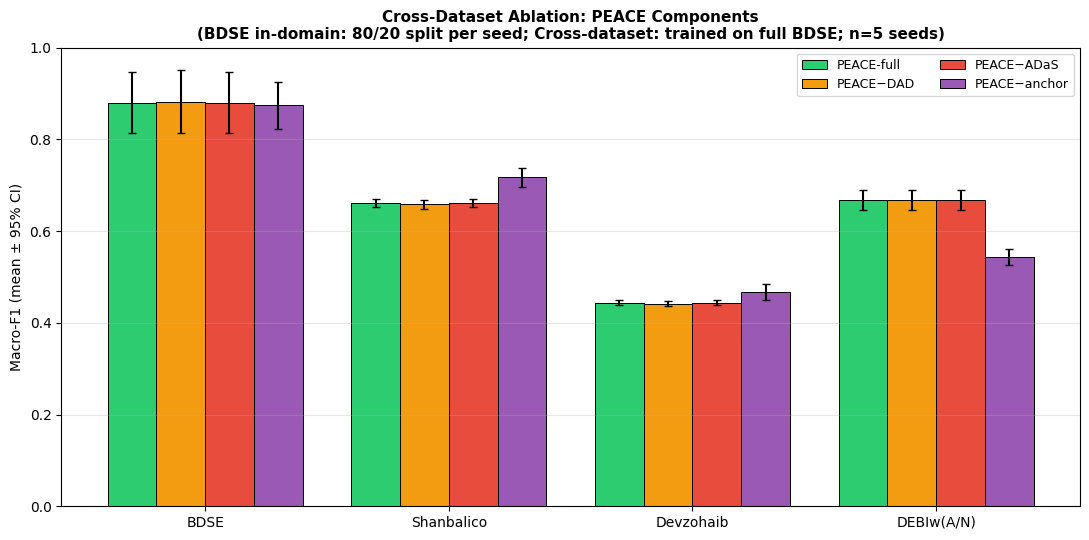

Saved: /kaggle/working/nb63_outputs/figure_ablation_FINAL.pdf


In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
TARGETS_PLOT = ['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']
x = np.arange(len(TARGETS_PLOT))
width = 0.20
colors_v = {'full':'#2ecc71', 'no_dad':'#f39c12', 'no_adas':'#e74c3c', 'no_anchor':'#9b59b6'}
labels_v = {'full':'PEACE-full', 'no_dad':'PEACE−DAD',
            'no_adas':'PEACE−ADaS', 'no_anchor':'PEACE−anchor'}

for i, var in enumerate(VARIANTS):
    means, errs = [], []
    for tgt in TARGETS_PLOT:
        sub = abl_sum_df[(abl_sum_df['variant']==var) & (abl_sum_df['test_tgt']==tgt)]
        if len(sub):
            means.append(sub.iloc[0]['mean_macro_f1'])
            errs.append(sub.iloc[0]['ci95_half'] if not pd.isna(sub.iloc[0]['ci95_half']) else 0)
        else:
            means.append(0.0); errs.append(0.0)
    ax.bar(x + (i-1.5)*width, means, width, yerr=errs, capsize=3,
           label=labels_v[var], color=colors_v[var],
           edgecolor='black', linewidth=0.7)

ax.set_xticks(x); ax.set_xticklabels(TARGETS_PLOT)
ax.set_ylabel('Macro-F1 (mean ± 95% CI)')
ax.set_title('Cross-Dataset Ablation: PEACE Components\n'
             '(BDSE in-domain: 80/20 split per seed; Cross-dataset: trained on full BDSE; n=5 seeds)',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()

out_pdf = os.path.join(CFG['output_dir'], 'figure_ablation_FINAL.pdf')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_pdf.replace('.pdf','.png'), bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {out_pdf}")


In [17]:
print("\n" + "="*72)
print("NOTEBOOK 6.3 — FINAL SUMMARY")
print("="*72)

print("\n--- Mean macro-F1 per variant per target ---")
piv = abl_sum_df.pivot(index='variant', columns='test_tgt', values='mean_macro_f1')
piv = piv[['BDSE','Shanbalico','Devzohaib','DEBIw(A/N)']].reindex(VARIANTS)
print(piv.round(4).to_string())

print("\n--- Cross-dataset only (mean across Shan+Dev+DEBIw) ---")
xfer = ['Shanbalico','Devzohaib','DEBIw(A/N)']
for var in VARIANTS:
    sub = abl_df[(abl_df['variant']==var) & (abl_df['test_tgt'].isin(xfer))]
    if len(sub):
        m = sub['macro_f1'].mean(); s = sub['macro_f1'].std(ddof=1)
        print(f"  {var:12s}: {m:.4f} ± {s:.4f}  (n={len(sub)})")

print(f"\n--- Files in {CFG['output_dir']} ---")
for f in sorted(os.listdir(CFG['output_dir'])):
    sz = os.path.getsize(os.path.join(CFG['output_dir'], f))
    print(f"  {f:55s}  {sz/1024:.1f} KB")

print("\nDone. This is the final ablation table for the paper.")



NOTEBOOK 6.3 — FINAL SUMMARY

--- Mean macro-F1 per variant per target ---
test_tgt     BDSE  Shanbalico  Devzohaib  DEBIw(A/N)
variant                                             
full       0.8797      0.6614     0.4436      0.6683
no_dad     0.8825      0.6588     0.4415      0.6685
no_adas    0.8797      0.6614     0.4436      0.6683
no_anchor  0.8744      0.7172     0.4664      0.5440

--- Cross-dataset only (mean across Shan+Dev+DEBIw) ---
  full        : 0.5911 ± 0.1085  (n=15)
  no_dad      : 0.5896 ± 0.1090  (n=15)
  no_adas     : 0.5911 ± 0.1085  (n=15)
  no_anchor   : 0.5759 ± 0.1094  (n=15)

--- Files in /kaggle/working/nb63_outputs ---
  ablation_wilcoxon_FINAL.csv                              0.6 KB
  cross_dataset_ablation_results_FINAL.csv                 6.7 KB
  cross_dataset_ablation_summary_FINAL.csv                 1.3 KB
  figure_ablation_FINAL.pdf                                28.5 KB
  figure_ablation_FINAL.png                                139.1 KB

Done. Th